In [3]:
#Load and split the MNIST dataset
from sklearn.datasets import fetch_openml
from tensorflow.keras.datasets import mnist

# Load MNIST dataset from Keras
(X_train_all, y_train_all), (X_test, y_test) = mnist.load_data()
X, y = X_train_all, y_train_all

X_train_all, X_test = X[:1000], X[600:]
y_train_all, y_test = y[:1000], y[600:]



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 10s 1us/step


In [4]:
X_train = X_train_all[:1000]
X_validation = X_train_all[1000:2000]
y_train = y_train_all[:1000]
y_validation = y_train_all[1000:2000]

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Validation set shape: {X_validation.shape}, {y_validation.shape}")
print(f"Test set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (1000, 28, 28), (1000,)
Validation set shape: (0, 28, 28), (0,)
Test set shape: (59400, 28, 28), (59400,)


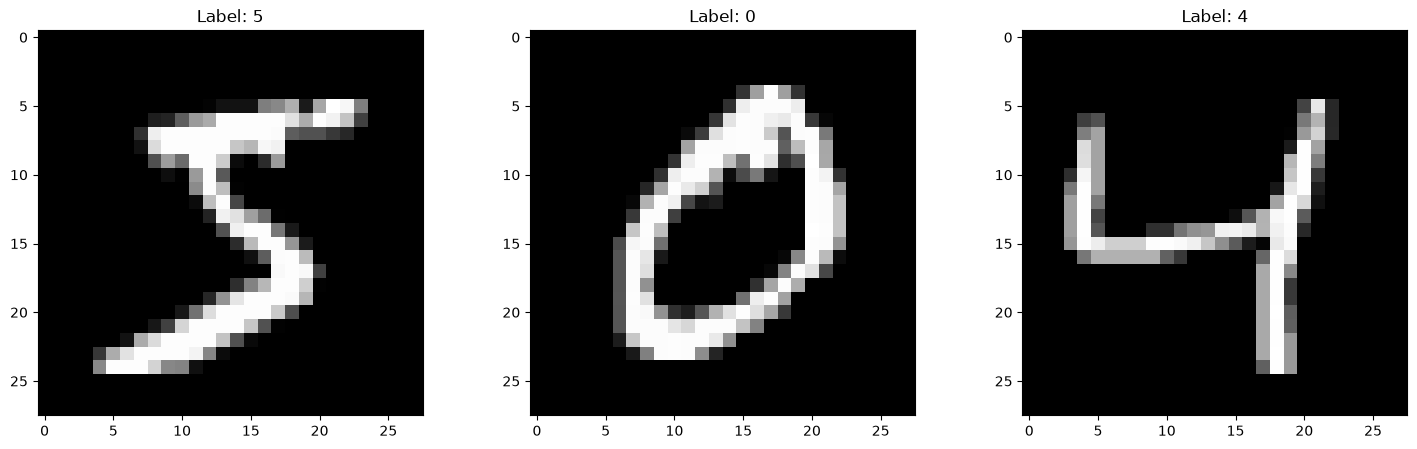

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))
for i in range(3):
  plt.subplot(1, 3, i + 1)
  plt.imshow(X_train[i], cmap='gray')
  plt.title(f'Label: {y_train[i]}')
  plt.axis(True)
plt.show()

In [6]:
X_train = X_train.reshape(X_train.shape[0], 28 * 28)
X_train = X_train.astype('float32') / 255.0

X_test = X_test.reshape(X_test.shape[0], 28 * 28)
X_test = X_test.astype('float32') / 255.0

X_validation = X_validation.reshape(X_validation.shape[0], 28 * 28)
X_validation = X_validation.astype('float32') / 255.0

In [7]:
# load the Fashion MNIST dataset
from tensorflow.keras.datasets import fashion_mnist

(X_train_all, y_train_all), (X_test, y_test) = fashion_mnist.load_data()

# The labels in the fashion MNIST dataset are integers from 0 to 9, representing different clothing categories. We can map these integers to their corresponding class names for better understanding.
print(y_train_all[0:9])  # Print the first 10 labels

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 26s 1us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
[9 0 0 3 0 2 7 2 5]


In [8]:
from tensorflow.keras.utils import to_categorical

y_train_onehot = to_categorical(y_train_all, num_classes=10)
print(y_train_onehot[0:9])  # Print the first 10 one-hot encoded labels

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]


In [9]:
# convert the labels to one-hot encoding
y_train = to_categorical(y_train, num_classes=10)
y_validation = to_categorical(y_validation, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)


In [10]:
import tensorflow as tf
# instantiate the model
model = tf.keras.Sequential()

#build the model architecture
model.add(tf.keras.layers.Dense(128, activation='relu', input_shape=(784,))) 
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))  # output layer with 10 classes

# display summary of the model architecture
model.summary()

c:\Users\markn\.conda\envs\deep_learning\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [12]:
# train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_validation, y_validation))

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.4040 - loss: 1.9540
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7600 - loss: 1.0762


c:\Users\markn\.conda\envs\deep_learning\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8530 - loss: 0.5853
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8980 - loss: 0.4063
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9150 - loss: 0.3180 
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9380 - loss: 0.2462
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9590 - loss: 0.2034
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9680 - loss: 0.1682 
Epoch 9/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9790 - loss: 0.1355
Epoch 10/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9810 - loss: 0.1173
